In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
#create dataset with 100 customers and 5 columns
np.random.seed(42)
data={'customerID':np.arange(1,101),'Age':np.random.randint(18,65,size=100),
      'Average_spend':np.random.uniform(5,50,size=100),
      'Visits_per_week':np.random.uniform(1,7,size=100),
      'Promotion_Interest':np.random.randint(1,11,size=100)}
df=pd.DataFrame(data)
df.head()


,customerID,Age,Average_spend,Visits_per_week,Promotion_Interest
0,1,56,18.206968,5.266897,2
1,2,46,5.633592,5.857006,9
2,3,32,13.947908,3.091996,8
3,4,60,37.010388,1.577059,10
4,5,25,40.557899,6.643140,7


C:\Users\dashm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dashm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dashm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\dashm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

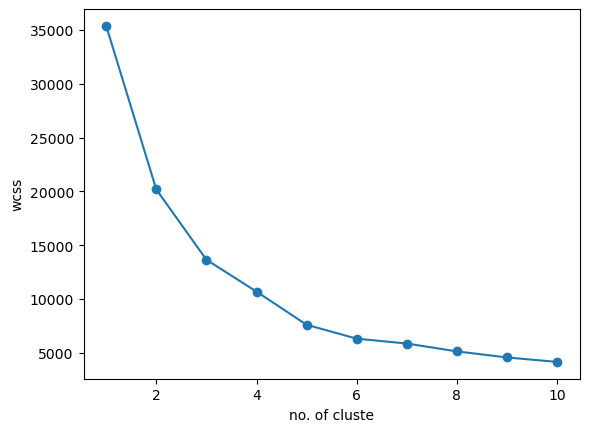

In [4]:
#find cluster number
#elbow method
x=df[['Age','Average_spend','Visits_per_week','Promotion_Interest']]
sse=[]
k_range=range(1,11)
for k in k_range:
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit(x)
    sse.append(kmeans.inertia_)
#here my main focus to minimize inertia
plt.plot(k_range,sse,marker='o')
plt.xlabel('no. of cluster')
plt.ylabel('wcss')
plt.show()

In [6]:
features=df[['Age','Average_spend','Visits_per_week','Promotion_Interest']]
kmeans=KMeans(n_clusters=3,random_state=42)
df['cluster']=kmeans.fit_predict(features)
df

C:\Users\dashm\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,customerID,Age,Average_spend,Visits_per_week,Promotion_Interest,cluster
0,1,56,18.206968,5.266897,2,2
1,2,46,5.633592,5.857006,9,2
2,3,32,13.947908,3.091996,8,2
3,4,60,37.010388,1.577059,10,0
4,5,25,40.557899,6.643140,7,1
...,...,...,...,...,...,...
95,96,24,27.868945,1.819728,10,1
96,97,26,36.311576,5.253466,10,1
97,98,41,43.626146,4.316920,3,0
98,99,18,19.668151,2.779061,10,1


In [7]:
#rename cluster to daily,promotion,weekend
cluster_names={0:'Daily',1:'Promotion',2:'weekend'}
df['customer_group']=df['cluster'].map(cluster_names)
df.head()

,customerID,Age,Average_spend,Visits_per_week,Promotion_Interest,cluster,customer_group
0,1,56,18.206968,5.266897,2,2,weekend
1,2,46,5.633592,5.857006,9,2,weekend
2,3,32,13.947908,3.091996,8,2,weekend
3,4,60,37.010388,1.577059,10,0,Daily
4,5,25,40.557899,6.643140,7,1,Promotion


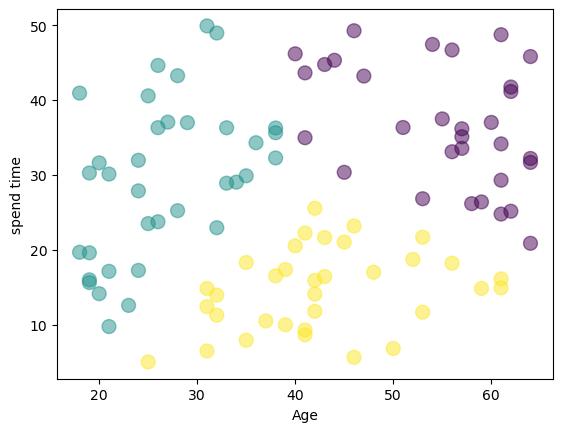

In [9]:
plt.scatter(df['Age'],df['Average_spend'],c=df['cluster'],cmap='viridis',marker='o',s=100,alpha=0.5)
plt.xlabel('Age')
plt.ylabel('spend time')
plt.show()

In [11]:
#sillhouette score
print(silhouette_score(features,df['cluster']))


0.36846369703368004


In [13]:
import pickle
pickle.dump(kmeans,open("kmeans.pkl",'wb'))
kmeans=pickle.load(open("kmeans.pkl","rb"))


In [14]:
def clustering(age,avg_spend,visit_per_week,promotion_interest):
    new_customer=np.array([[age,avg_spend,visit_per_week,promotion_interest]])
    predicted_cluster=kmeans.predict(new_customer)
    if predicted_cluster[0]==0:
        return "Daily"
    elif predicted_cluster[0]==1:
        return "weekend"
    else:
        return "Promotion"
        

In [15]:
#new customer
age=41
avg_spend=30
visit_per_week=4
promotion_interest=7
clustering(age,avg_spend,visit_per_week,promotion_interest)

C:\Users\dashm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


'weekend'